## Importación de librerías

In [2]:
!pip install pandas openpyxl


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

# Ruta del archivo Excel
archivo_excel = '../data/raw/customer-details.xlsx'

# Leer todas las hojas en un diccionario
hojas = pd.read_excel(archivo_excel, sheet_name=None)

# Ver los nombres de las hojas
print("Hojas encontradas:", hojas.keys())

Hojas encontradas: dict_keys(['2012', '2013', '2014'])


In [4]:
df_2012 = hojas['2012']
df_2013 = hojas['2013']
df_2014 = hojas['2014']

In [5]:
# Tratamiento de datos
import pandas as pd

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de ruta
import sys
sys.path.append('../')

# Importar funciones
from src.soporte import analisis_rapido, eda, matriz_correlacion

## Carga de datos

In [6]:
import pandas as pd

df = pd.read_excel('../data/output/customer-details_multihoja.xlsx', sheet_name=None)

# Acceder a cada hoja por su nombre
df_2012 = df['2012']
df_2013 = df['2013']
df_2014 = df['2014']


## Objetivos del análisis

* Entender el perfil general de los clientes del banco entre los años 2012, 2013 y 2014.

* Analizar cómo influyen factores como `Income`, `Kidhome`, `Teenhome`, `Dt_customer` y `NumWebVisitsMonth` en la decisión del cliente.

* Comparar la evolución temporal de las variables.

* Filtrar y centrar el análisis en registros consistentes y representativos para evitar sesgos en las conclusiones.

## Vamos a empezar haciendo el EDA para el año 2012

In [7]:
df_2012.head()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


### Análisis

In [8]:
def analisis_rapido(df_2012, n=5):
    """ 
    Función que proporciona un análisis rápido del DataFrame.

    Parámetros:
    df: DataFrame
    n: Número de filas (por defecto = 5)
    """

    print(f"Las {n} primeras columnas son:")
    display(df_2012.head(n))
    print("Información básica del DataFrame:")
    display(df_2012.info())

    print(f"El número de duplicados es: {df_2012.duplicated().sum()}")
    display(df_2012.isna().mean().round(4) * 100)

In [9]:
analisis_rapido(df_2012, 3)

Las 3 primeras columnas son:


,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b


Información básica del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20115 entries, 0 to 20114
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         20115 non-null  int64         
 1   Income             20115 non-null  int64         
 2   Kidhome            20115 non-null  int64         
 3   Teenhome           20115 non-null  int64         
 4   Dt_Customer        20115 non-null  datetime64[ns]
 5   NumWebVisitsMonth  20115 non-null  int64         
 6   ID                 20115 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 1.1+ MB


None

El número de duplicados es: 0


Unnamed: 0           0.0
Income               0.0
Kidhome              0.0
Teenhome             0.0
Dt_Customer          0.0
NumWebVisitsMonth    0.0
ID                   0.0
dtype: float64

No tenemos duplicados ya que está limpia la BD.

### Columnas del dataset

●	``income``: Representa el ingreso anual del cliente en términos monetarios.

●	``kidcome``: Indica el número de niños en el hogar del cliente.

●	``teenhome``: Indica el número de adolescentes en el hogar del cliente.

●	``dt_customer``: Representa la fecha en que el cliente se convirtió en cliente de la empresa.

●	``numwebvisitsmonth``: Indica la cantidad de visitas mensuales del cliente al sitio web de la empresa.

●	``id``: Identificador único del cliente.

### EDA

Variables numéricas:

 Index(['Unnamed: 0', 'Income', 'Kidhome', 'Teenhome', 'NumWebVisitsMonth',
       'Customer_Year', 'Customer_Month', 'Acumulado'],
      dtype='object')

Variables categóricas:

 Index(['ID', 'Customer_DayOfWeek'], dtype='object')
Veamos las estadísticas básicas:



,count,mean,min,25%,50%,75%,max,std
Unnamed: 0,20115.0,10057.0,0.0,5028.5,10057.0,15085.5,20114.0,5806.844668
Income,20115.0,93087.213224,5852.0,49110.0,92962.0,136705.0,180791.0,50614.798255
Kidhome,20115.0,1.004176,0.0,0.0,1.0,2.0,2.0,0.816811
Teenhome,20115.0,0.999503,0.0,0.0,1.0,2.0,2.0,0.815298
Dt_Customer,20115,2012-07-01 17:15:14.362416128,2012-01-01 00:00:00,2012-04-01 00:00:00,2012-07-02 00:00:00,2012-09-30 00:00:00,2012-12-31 00:00:00,NaN
NumWebVisitsMonth,20115.0,16.54079,1.0,9.0,16.0,25.0,32.0,9.235324
Customer_Year,20115.0,2012.0,2012.0,2012.0,2012.0,2012.0,2012.0,0.0
Customer_Month,20115.0,6.519861,1.0,4.0,7.0,9.0,12.0,3.45
Acumulado,20115.0,10058.0,1.0,5029.5,10058.0,15086.5,20115.0,5806.844668


,count,unique,top,freq
ID,20115,20115,e5c13bad-98bd-49dd-8852-97bd0f74c75f,1
Customer_DayOfWeek,20115,7,Monday,2971


 
---------- ESTAMOS ANALIZANDO LA COLUMNA: 'ID' ----------
Valores únicos: ['eafc6a46-721f-4210-92b2-3e90b4b875bb'
 '0a4d492a-fbec-4951-875e-257f217358ae'
 '9aafbafa-8741-483a-bc25-e6da7eea3457' ...
 '46b8cd0e-0996-4c52-b554-bd6a6b790b96'
 '7763844f-1c68-4706-a058-c09863240ecb'
 'e5c13bad-98bd-49dd-8852-97bd0f74c75f']

Frecuencia de los valores únicos de las categorías


ID
e5c13bad-98bd-49dd-8852-97bd0f74c75f    1
eafc6a46-721f-4210-92b2-3e90b4b875bb    1
0a4d492a-fbec-4951-875e-257f217358ae    1
2c26bc25-ce90-4a6a-a2d2-ad9253c48e05    1
9a52213a-6f13-4e5c-befe-a8c6cc09483d    1
                                       ..
3a0659aa-1d11-4a54-8ae5-ade5f005ea36    1
7099a423-9d78-4a03-9471-18182e224902    1
7aabd812-0045-4150-887d-cfe07595868f    1
0a86b146-9a87-44fa-86e1-60034d2dcf9d    1
08e896e9-6787-43f6-942c-dded65dc3434    1
Name: count, Length: 20115, dtype: int64

 
---------- ESTAMOS ANALIZANDO LA COLUMNA: 'Customer_DayOfWeek' ----------
Valores únicos: ['Sunday' 'Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday']

Frecuencia de los valores únicos de las categorías


Customer_DayOfWeek
Monday       2971
Friday       2908
Sunday       2890
Wednesday    2863
Tuesday      2848
Thursday     2840
Saturday     2795
Name: count, dtype: int64

Vayamos con los countplots:

Columna ID tiene demasiadas categorías (20115)




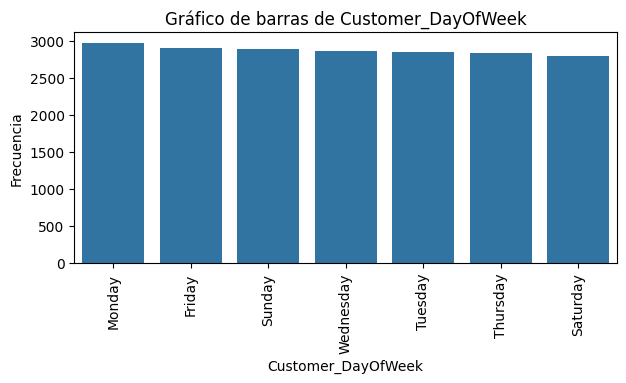

Vayamos con los histogramas:



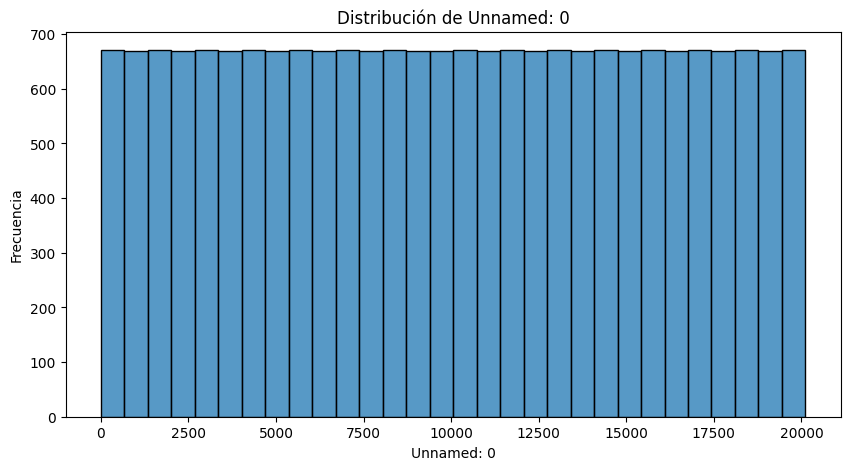

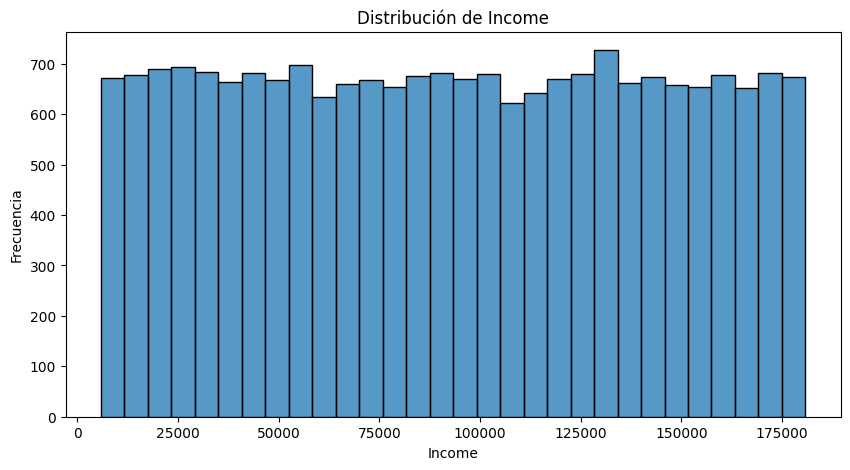

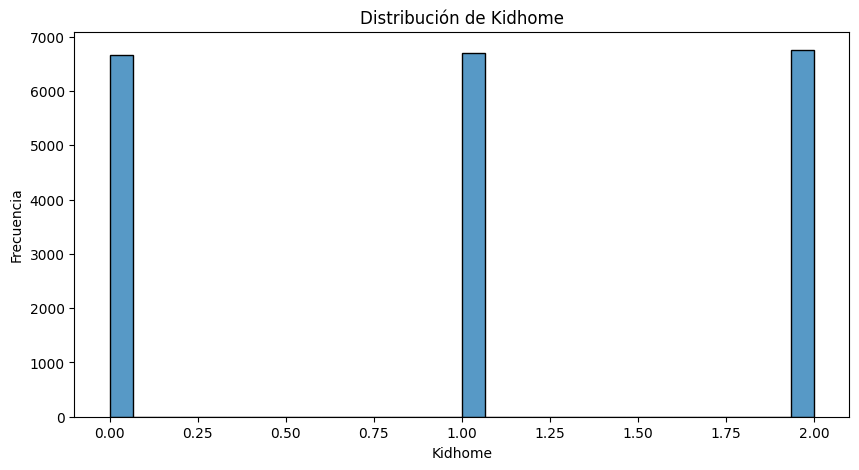

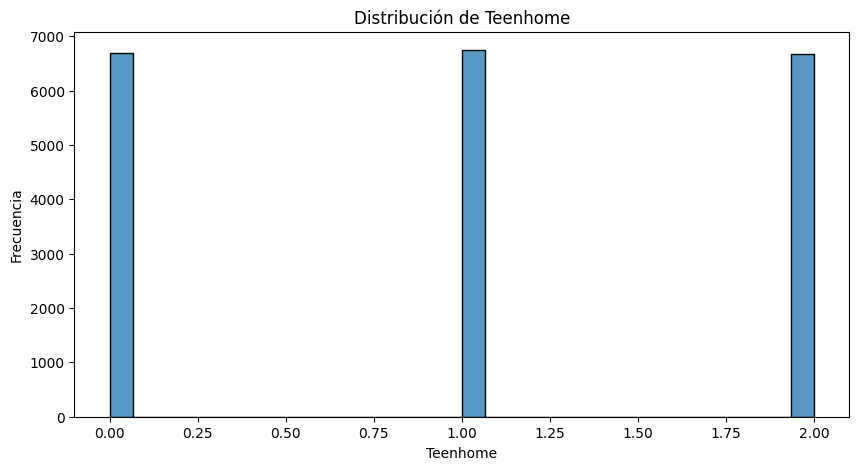

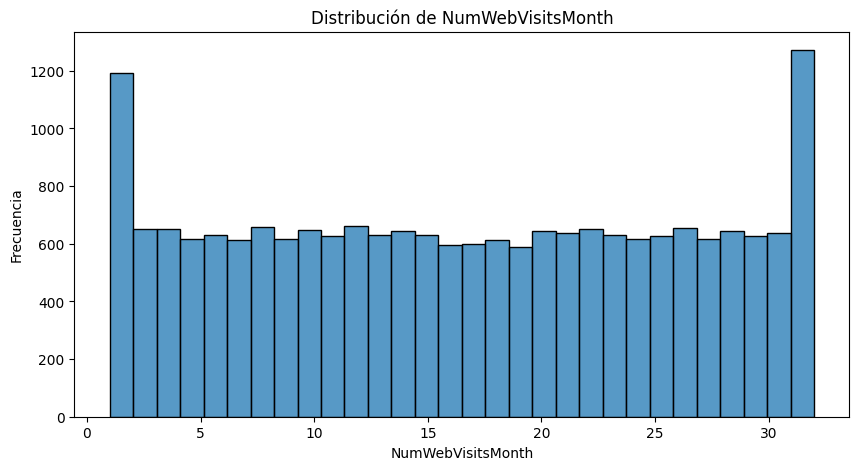

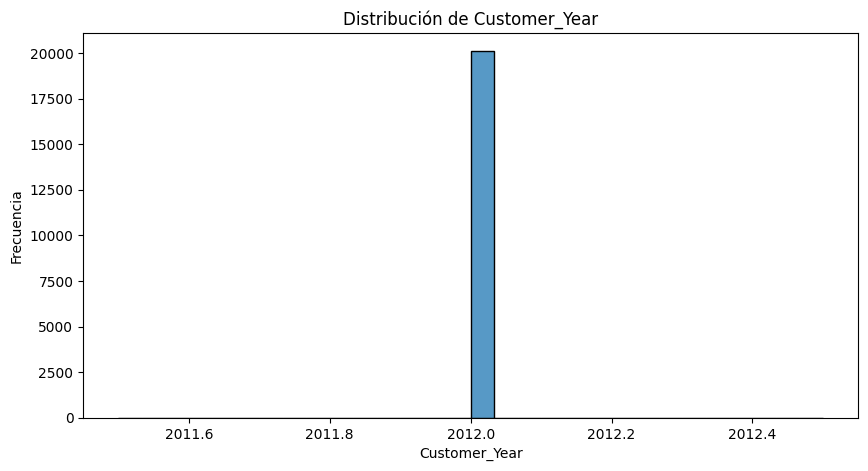

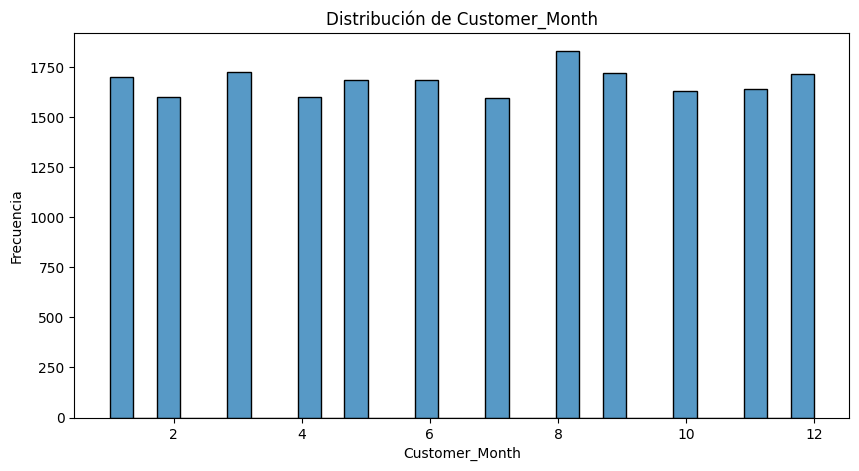

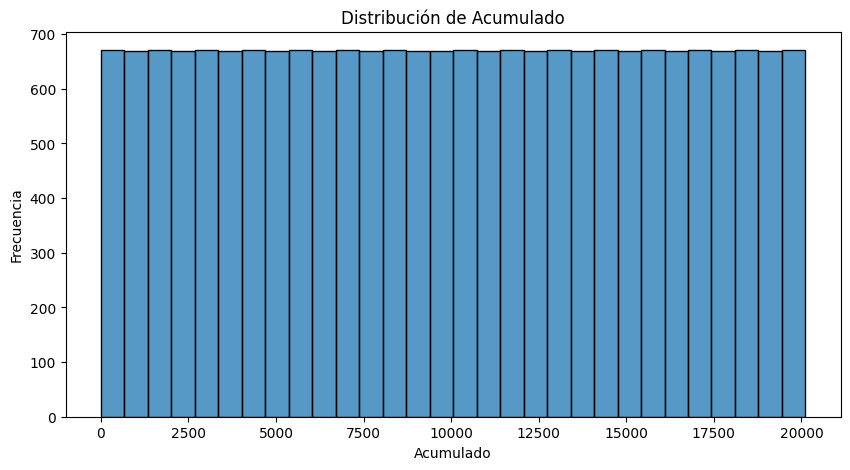

Vayamos con los boxplots:



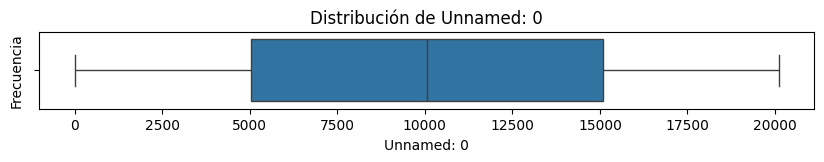

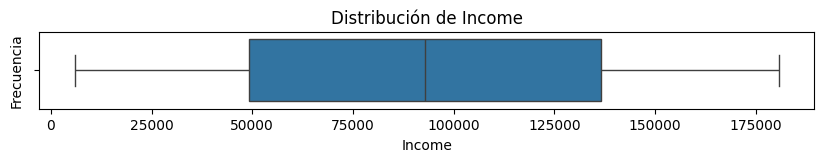

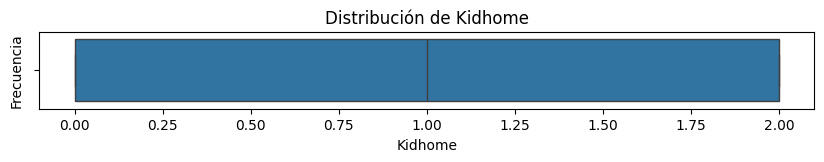

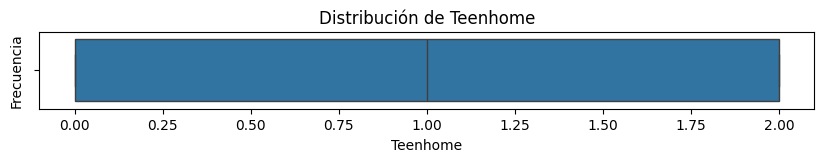

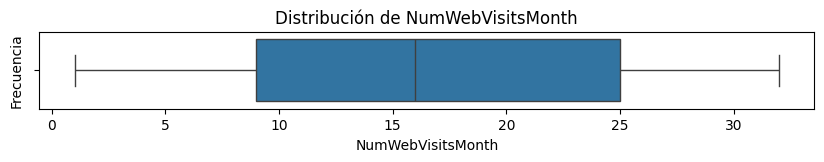

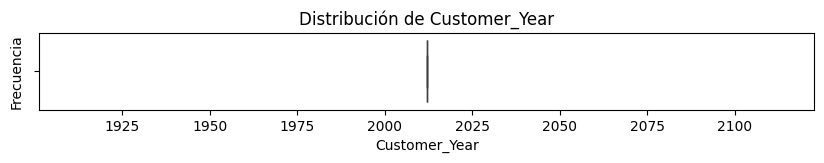

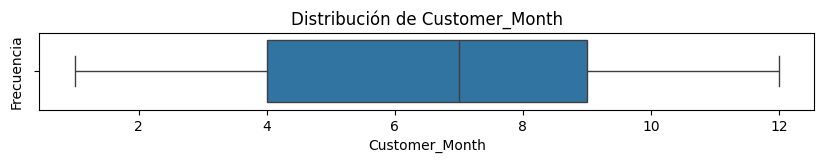

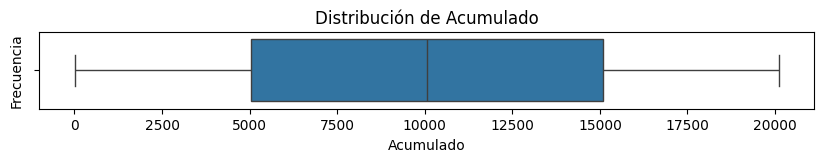

In [30]:
eda(df_2012)

Cómo no coge la colunma `Dt_costumer` haré su análisis de otra manera:

In [11]:
# Convertir la columna a formato fecha

df_2012["Dt_Customer"] = pd.to_datetime(df_2012["Dt_Customer"], errors='coerce')


In [12]:
# Extraer componentes de fecha útiles

df_2012["Customer_Year"] = df_2012["Dt_Customer"].dt.year
df_2012["Customer_Month"] = df_2012["Dt_Customer"].dt.month
df_2012["Customer_Quarter"] = df_2012["Dt_Customer"].dt.to_period("Q")
df_2012["Customer_DayOfWeek"] = df_2012["Dt_Customer"].dt.day_name()


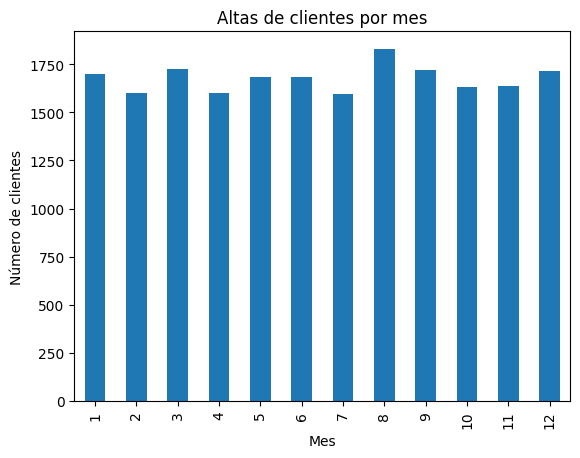

In [32]:
# Visualizar nuevas altas de clientes por mes

df_2012["Customer_Month"].value_counts().sort_index().plot(kind='bar')
plt.title("Altas de clientes por mes")
plt.xlabel("Mes")
plt.ylabel("Número de clientes")
plt.show()



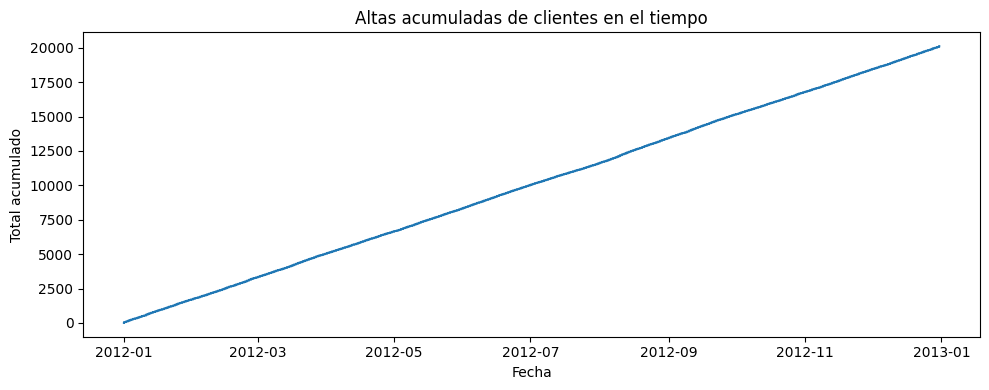

In [14]:
# Altas acumuladas por mes a lo largo del tiempo

df_2012.sort_values("Dt_Customer", inplace=True)
df_2012["Acumulado"] = range(1, len(df_2012)+1)

plt.figure(figsize=(10, 4))
plt.plot(df_2012["Dt_Customer"], df_2012["Acumulado"])
plt.title("Altas acumuladas de clientes en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Total acumulado")
plt.tight_layout()
plt.show()


### Matriz correlación

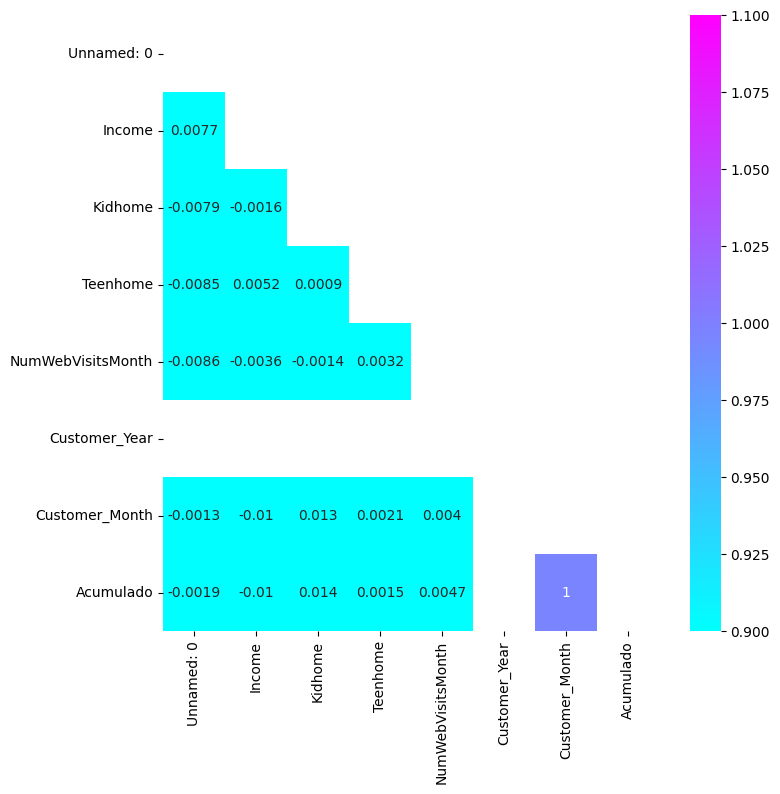

In [15]:
matriz_correlacion(df_2012)

Viendo la matriz correlación sacamos la conclusión de que ninguna variable muestra correlaciones significativas (resultados cercanos a 0).

### Relaciones cruzadas

In [16]:
df_2012.columns

Index(['Unnamed: 0', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer',
       'NumWebVisitsMonth', 'ID', 'Customer_Year', 'Customer_Month',
       'Customer_Quarter', 'Customer_DayOfWeek', 'Acumulado'],
      dtype='object')

### Análisis ingresos vs total de niños en el hogar

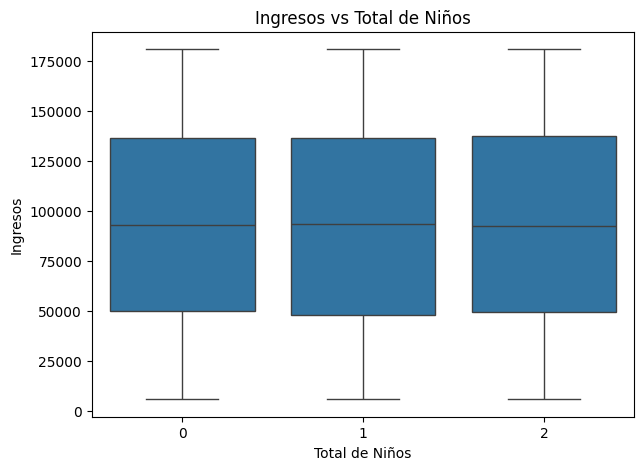

In [17]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Kidhome', y='Income', data=df_2012)
plt.title("Ingresos vs Total de Niños")
plt.xlabel("Total de Niños")
plt.ylabel("Ingresos")
plt.show()

* La mayoría de los clientes con 0 o 1 niño presentan una mediana de ingresos similar, en torno a ~93.000.

* No hay grandes diferencias en el rango de ingresos en función del número de niños.

* Los clientes con 2 niños tienen una ligera disminución en la mediana, pero hay muchísima dispersión en todos los grupos.

* Conclusión: El número total de niños en casa no influye significativamente en los ingresos de los clientes.

### Análisis ingresos vs total de adolescentes en el hogar

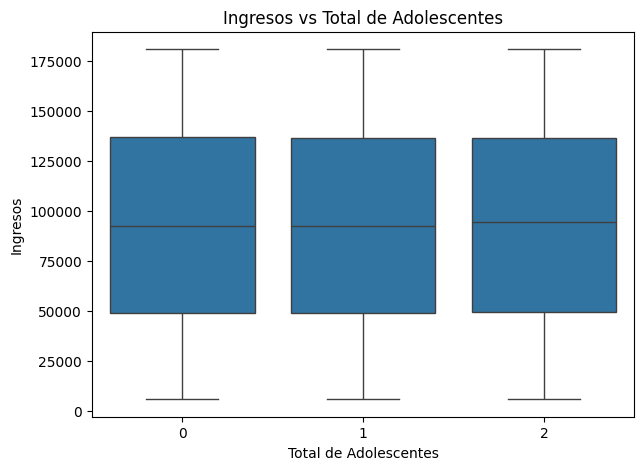

In [18]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Teenhome', y='Income', data=df_2012)
plt.title("Ingresos vs Total de Adolescentes")
plt.xlabel("Total de Adolescentes")
plt.ylabel("Ingresos")
plt.show()

* Sigue el mismo patrón que el gráfico de ingresos vs total de niños en el hogar del cliente, por lo que las conclusiones a las que podemos llegar son idénticas.

### Análisis ingresos vs visitas web por mes

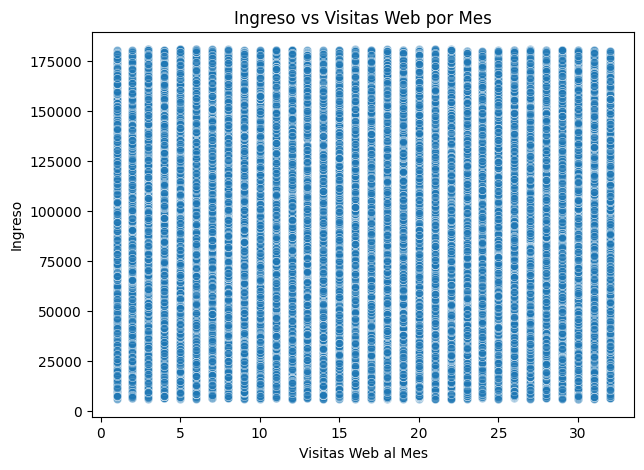

In [19]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='NumWebVisitsMonth', y='Income', data=df_2012, alpha=0.6)
plt.title("Ingreso vs Visitas Web por Mes")
plt.xlabel("Visitas Web al Mes")
plt.ylabel("Ingreso")
plt.show()

* No hay una tendencia clara entre número de visitas y nivel de ingreso.

* La nube de puntos está distribuida horizontalmente, con ingresos altos y bajos en todos los niveles de visitas.

* Conclusión: El número de visitas web mensuales no depende del nivel de ingreso. Esto sugiere que el comportamiento online puede estar influido por otros factores.

### Ingresos según el mes de captación

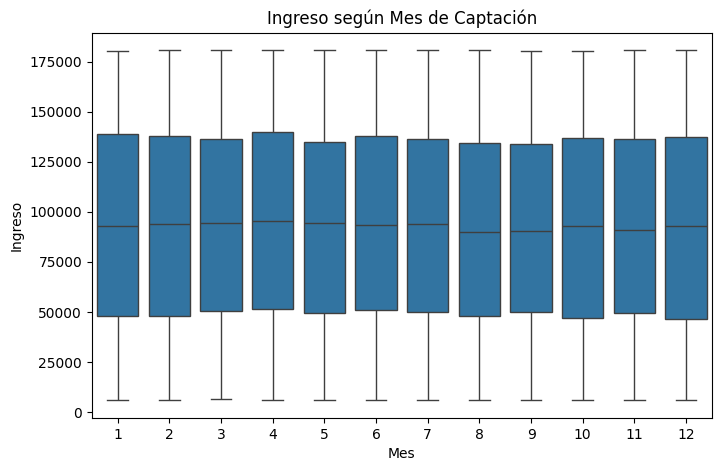

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Customer_Month', y='Income', data=df_2012)
plt.title("Ingreso según Mes de Captación")
plt.xlabel("Mes")
plt.ylabel("Ingreso")
plt.show()

* La mediana de ingreso es relativamente constante durante todo el año.

* Todos los meses siguen el mismo patrón, no hay apenas variación en cuanto al mes de captación.

* Conclusión: El ingreso no varía significativamente según el mes en que el cliente se une al banco, lo cual es coherente si el banco no filtra por nivel económico a la hora de captar clientes.

## Análisis más profundo

* Distribución de ingresos por número de niños en el hogar.

* Ingresos promedio por número de visitas web.

* Altas clientes por mes.

* Visitas web según mes de captación.

### Distribución de ingresos por número de niños en el hogar

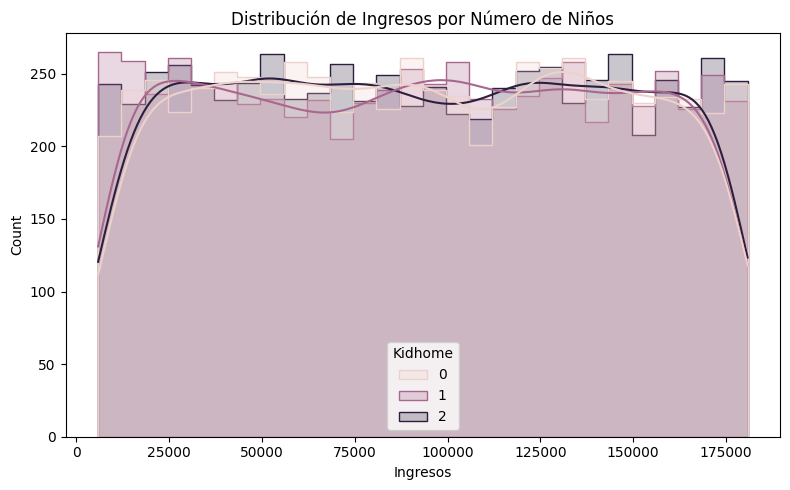

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_2012, x='Income', hue='Kidhome', kde=True, element='step')
plt.title("Distribución de Ingresos por Número de Niños")
plt.xlabel("Ingresos")
plt.tight_layout()
plt.show()

### Ingresos promedio por número de visitas web

NumWebVisitsMonth
1     93473.537415
2     93993.413907
3     93913.628834
4     95151.946154
5     96520.293355
6     94404.526232
7     93178.169935
8     93508.882801
9     91686.217180
10    90086.121726
11    90719.792332
12    91017.924585
13    92222.524564
14    90153.049767
15    90912.273450
16    94068.419463
17    95075.823333
18    95257.029412
19    93886.299320
20    93722.902022
21    90729.825472
22    93991.552308
23    93172.624801
24    95233.835772
25    91617.572568
26    93508.208270
27    93828.025932
28    95459.843653
29    94096.173567
30    90541.036164
31    91982.824477
32    92185.344086
Name: Income, dtype: float64


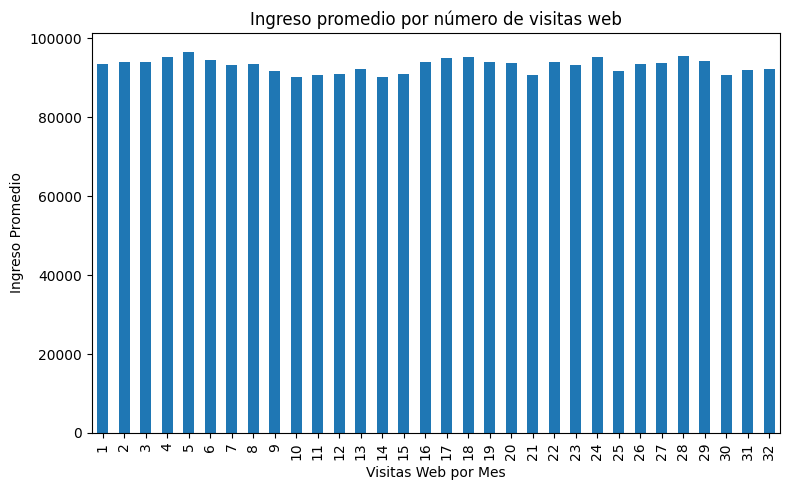

In [22]:
# Agrupación
promedios = df_2012.groupby('NumWebVisitsMonth')['Income'].mean()

# Mostrar resultados
print(promedios)

# Gráfico
plt.figure(figsize=(8, 5))
promedios.plot(kind='bar')
plt.title("Ingreso promedio por número de visitas web")
plt.xlabel("Visitas Web por Mes")
plt.ylabel("Ingreso Promedio")
plt.tight_layout()
plt.show()

### Altas clientes por mes

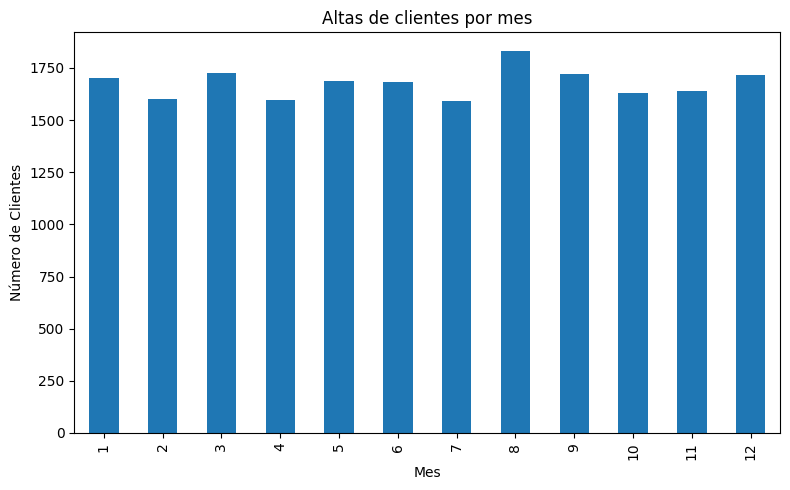

In [23]:
plt.figure(figsize=(8, 5))
df_2012['Customer_Month'].value_counts().sort_index().plot(kind='bar')
plt.title("Altas de clientes por mes")
plt.xlabel("Mes")
plt.ylabel("Número de Clientes")
plt.tight_layout()
plt.show()

### Visitas web según mes de captación

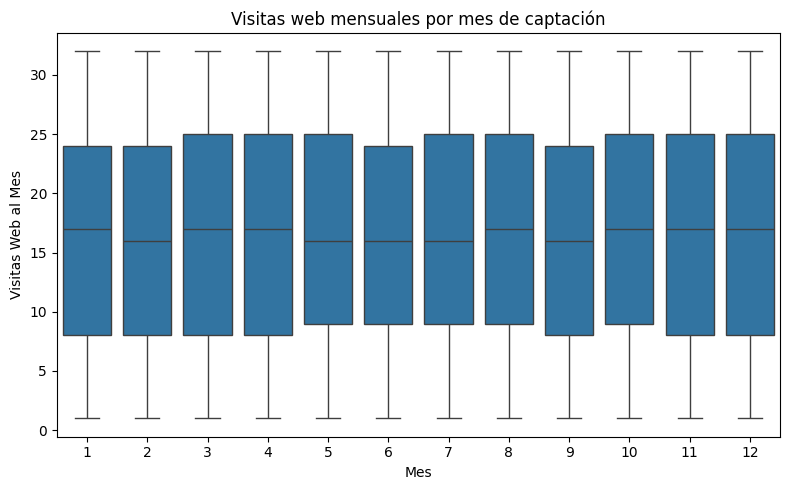

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Customer_Month', y='NumWebVisitsMonth', data=df_2012)
plt.title("Visitas web mensuales por mes de captación")
plt.xlabel("Mes")
plt.ylabel("Visitas Web al Mes")
plt.tight_layout()
plt.show()

## EDA año 2013

In [26]:
df_2013.head()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,82407,0,1,2013-10-07,29,ef81336c-e41a-46d0-8a30-5d4ac3b836be
1,1,24877,0,0,2013-04-21,32,50b224ac-84b4-42a7-aba9-3e1d1d620479
2,2,78839,1,0,2013-11-25,21,9cb15c53-b647-464a-add9-09cdae04897c
3,3,113859,1,1,2013-01-06,12,f8aaf334-949d-4943-a214-b64fe9c088b4
4,4,147317,0,0,2013-07-10,14,885fe85a-3718-4760-a32a-a57628cf7528


### Análisis

In [27]:
def analisis_rapido(df_2013, n=5):
    """ 
    Función que proporciona un análisis rápido del DataFrame.

    Parámetros:
    df: DataFrame
    n: Número de filas (por defecto = 5)
    """

    print(f"Las {n} primeras columnas son:")
    display(df_2013.head(n))
    print("Información básica del DataFrame:")
    display(df_2013.info())

    print(f"El número de duplicados es: {df_2013.duplicated().sum()}")
    display(df_2013.isna().mean().round(4) * 100)

In [28]:
analisis_rapido(df_2013, 3)

Las 3 primeras columnas son:


,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,82407,0,1,2013-10-07,29,ef81336c-e41a-46d0-8a30-5d4ac3b836be
1,1,24877,0,0,2013-04-21,32,50b224ac-84b4-42a7-aba9-3e1d1d620479
2,2,78839,1,0,2013-11-25,21,9cb15c53-b647-464a-add9-09cdae04897c


Información básica del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8965 entries, 0 to 8964
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         8965 non-null   int64         
 1   Income             8965 non-null   int64         
 2   Kidhome            8965 non-null   int64         
 3   Teenhome           8965 non-null   int64         
 4   Dt_Customer        8965 non-null   datetime64[ns]
 5   NumWebVisitsMonth  8965 non-null   int64         
 6   ID                 8965 non-null   object        
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 490.4+ KB


None

El número de duplicados es: 0


Unnamed: 0           0.0
Income               0.0
Kidhome              0.0
Teenhome             0.0
Dt_Customer          0.0
NumWebVisitsMonth    0.0
ID                   0.0
dtype: float64

No hay duplicados porque está limpia la BD.

### Columnas del dataset

●	`income`: Representa el ingreso anual del cliente en términos monetarios.

●	`kidcome`: Indica el número de niños en el hogar del cliente.

●	`teenhome`: Indica el número de adolescentes en el hogar del cliente.

●	`dt_customer`: Representa la fecha en que el cliente se convirtió en cliente de la empresa.

●	`numwebvisitsmonth`: Indica la cantidad de visitas mensuales del cliente al sitio web de la empresa.

●	`id`: Identificador único del cliente.

### EDA

Variables numéricas:

 Index(['Unnamed: 0', 'Income', 'Kidhome', 'Teenhome', 'NumWebVisitsMonth'], dtype='object')

Variables categóricas:

 Index(['ID'], dtype='object')
Veamos las estadísticas básicas:



,count,mean,min,25%,50%,75%,max,std
Unnamed: 0,8965.0,4482.0,0.0,2241.0,4482.0,6723.0,8964.0,2588.116915
Income,8965.0,92788.951255,5848.0,49866.0,92315.0,136063.0,180787.0,50188.145448
Kidhome,8965.0,0.991523,0.0,0.0,1.0,2.0,2.0,0.810005
Teenhome,8965.0,0.995761,0.0,0.0,1.0,2.0,2.0,0.814981
Dt_Customer,8965,2013-07-02 11:23:37.110987008,2013-01-01 00:00:00,2013-04-01 00:00:00,2013-07-03 00:00:00,2013-10-03 00:00:00,2013-12-31 00:00:00,NaN
NumWebVisitsMonth,8965.0,16.575683,1.0,9.0,17.0,25.0,32.0,9.259737


,count,unique,top,freq
ID,8965,8965,ba7fb638-c6cb-4dc8-aad4-75456c3818c5,1


 
---------- ESTAMOS ANALIZANDO LA COLUMNA: 'ID' ----------
Valores únicos: ['ef81336c-e41a-46d0-8a30-5d4ac3b836be'
 '50b224ac-84b4-42a7-aba9-3e1d1d620479'
 '9cb15c53-b647-464a-add9-09cdae04897c' ...
 '01b3ac53-b1bd-450a-be11-6893b3aeadd5'
 '8906c203-a13f-4b10-985c-bd72bd01a011'
 'ba7fb638-c6cb-4dc8-aad4-75456c3818c5']

Frecuencia de los valores únicos de las categorías


ID
ba7fb638-c6cb-4dc8-aad4-75456c3818c5    1
ef81336c-e41a-46d0-8a30-5d4ac3b836be    1
50b224ac-84b4-42a7-aba9-3e1d1d620479    1
9cb15c53-b647-464a-add9-09cdae04897c    1
f8aaf334-949d-4943-a214-b64fe9c088b4    1
                                       ..
3a0af125-f706-44dc-a554-dde13c6814dc    1
7731b479-e3ab-4b56-8b1f-338a20502f34    1
3b2aa797-4a36-4fe8-89d4-bfe8f51a8336    1
103ab480-e33c-459b-893c-b1666dc68bfe    1
270bcba2-2c09-42a8-ad3e-f40035969394    1
Name: count, Length: 8965, dtype: int64

Vayamos con los countplots:

Columna ID tiene demasiadas categorías (8965)


Vayamos con los histogramas:



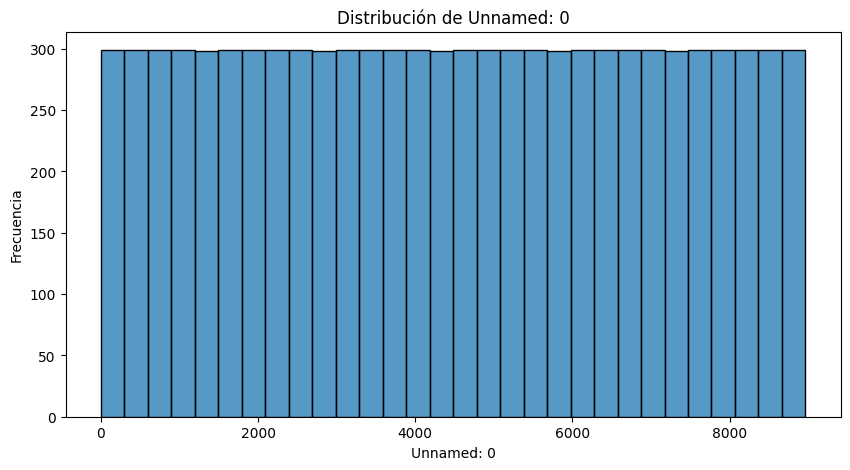

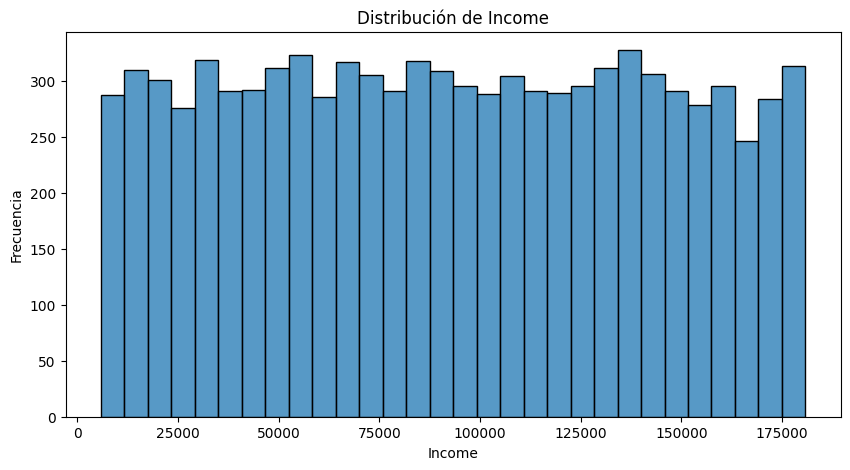

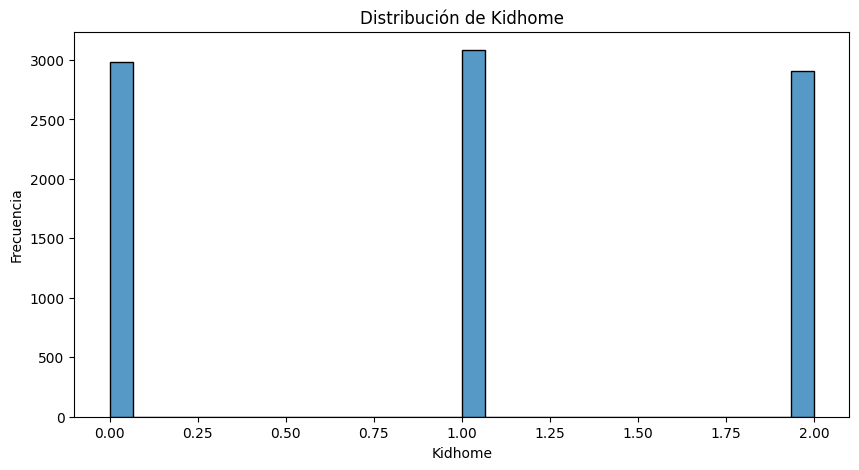

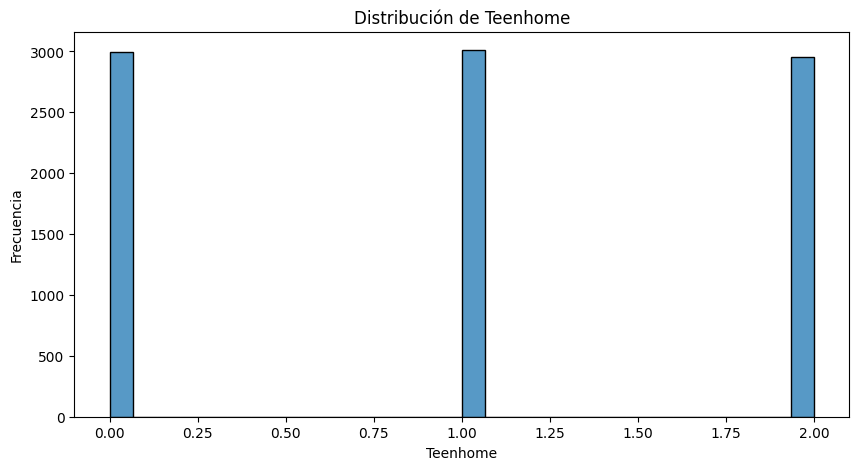

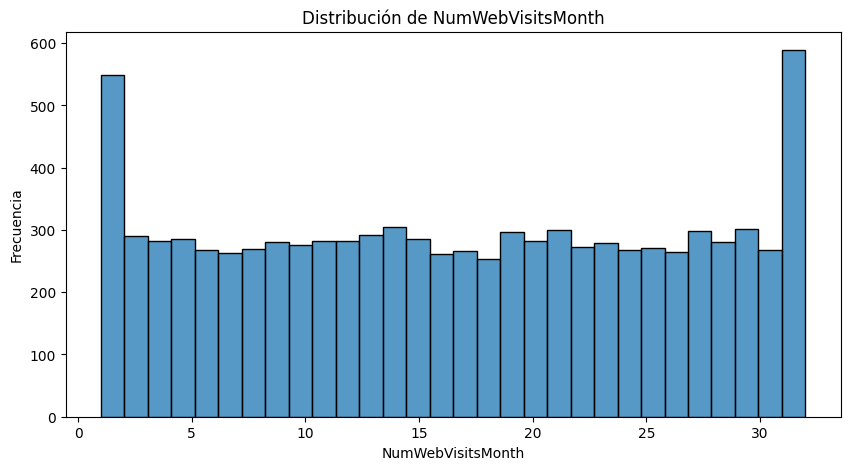

Vayamos con los boxplots:



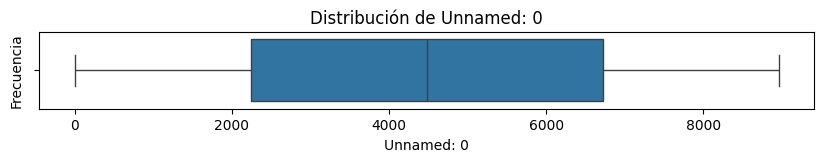

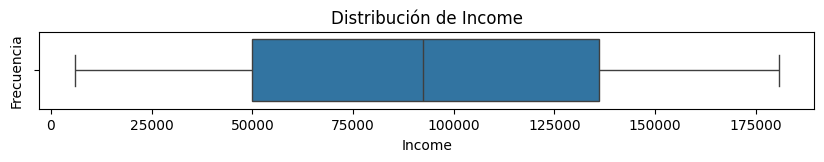

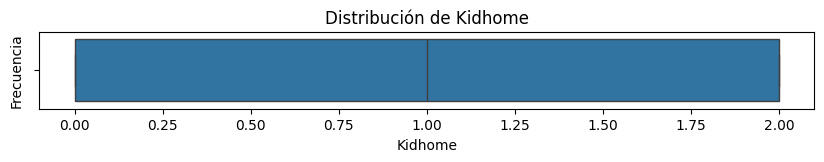

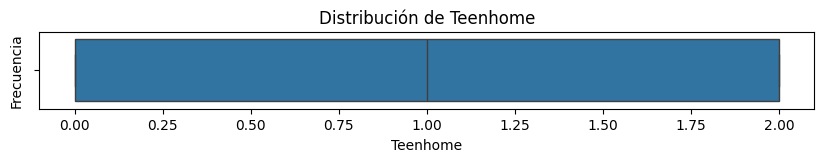

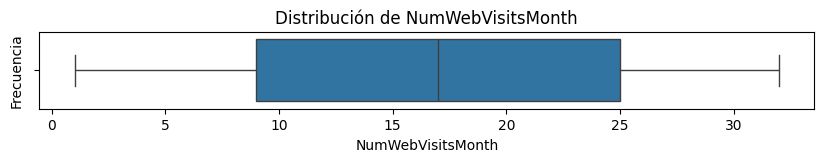

In [31]:
eda(df_2013)

Cómo no coge la colunma `Dt_costumer` haré su análisis de otra manera:

In [33]:
# Convertir la columna a formato fecha

df_2012["Dt_Customer"] = pd.to_datetime(df_2013["Dt_Customer"], errors='coerce')

In [36]:
# Extraer componentes de fecha útiles

df_2013["Customer_Year"] = df_2013["Dt_Customer"].dt.year
df_2013["Customer_Month"] = df_2013["Dt_Customer"].dt.month
df_2013["Customer_Quarter"] = df_2013["Dt_Customer"].dt.to_period("Q")
df_2013["Customer_DayOfWeek"] = df_2013["Dt_Customer"].dt.day_name()

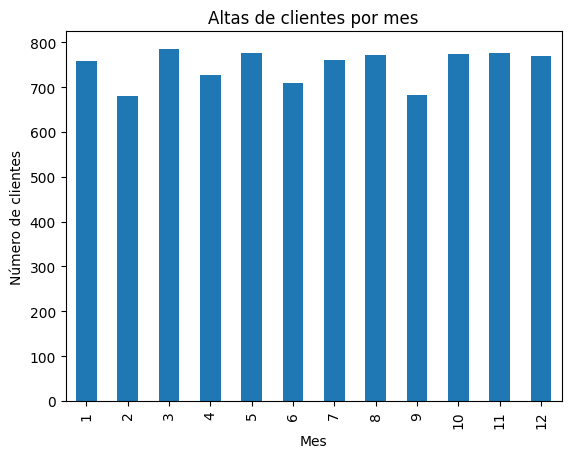

In [37]:
# Visualizar nuevas altas de clientes por mes

df_2013["Customer_Month"].value_counts().sort_index().plot(kind='bar')
plt.title("Altas de clientes por mes")
plt.xlabel("Mes")
plt.ylabel("Número de clientes")
plt.show()

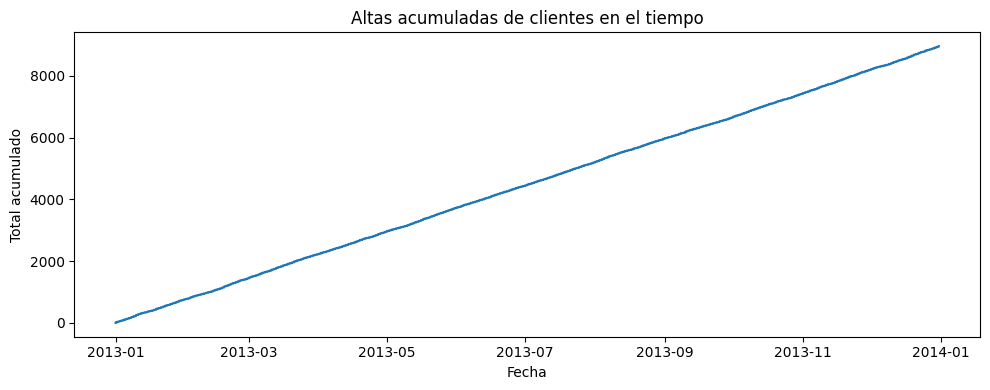

In [38]:
# Altas acumuladas por mes a lo largo del tiempo

df_2013.sort_values("Dt_Customer", inplace=True)
df_2013["Acumulado"] = range(1, len(df_2013)+1)

plt.figure(figsize=(10, 4))
plt.plot(df_2013["Dt_Customer"], df_2013["Acumulado"])
plt.title("Altas acumuladas de clientes en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Total acumulado")
plt.tight_layout()
plt.show()

### Matriz correlación

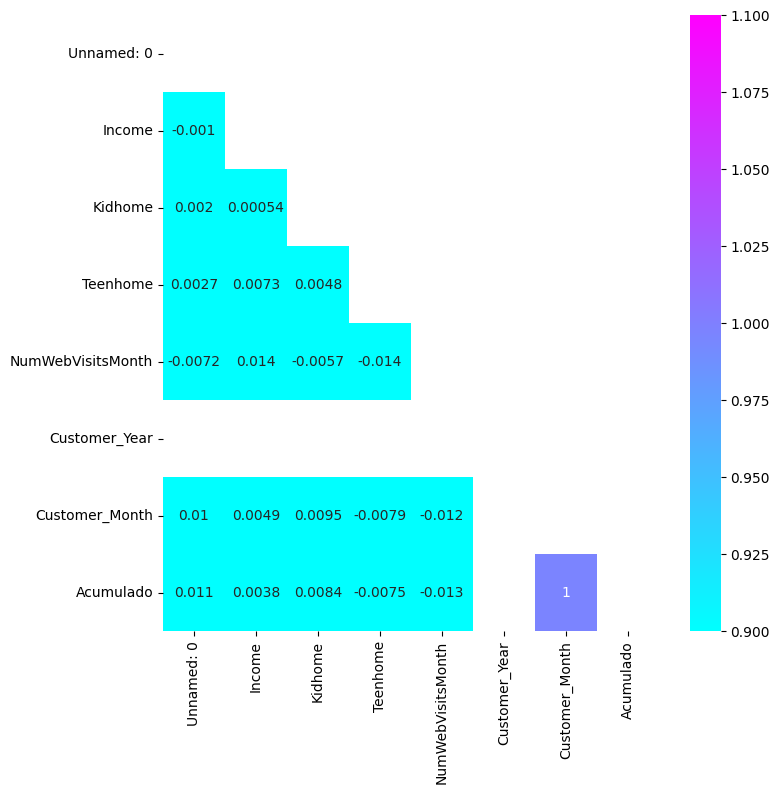

In [39]:
matriz_correlacion(df_2013)

Viendo la matriz correlación sacamos la conclusión de que ninguna variable muestra correlaciones significativas (resultados cercanos a 0).

### Relaciones cruzadas

In [40]:
df_2013.columns

Index(['Unnamed: 0', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer',
       'NumWebVisitsMonth', 'ID', 'Customer_Year', 'Customer_Month',
       'Customer_Quarter', 'Customer_DayOfWeek', 'Acumulado'],
      dtype='object')

### Análisis ingresos vs total de niños en el hogar

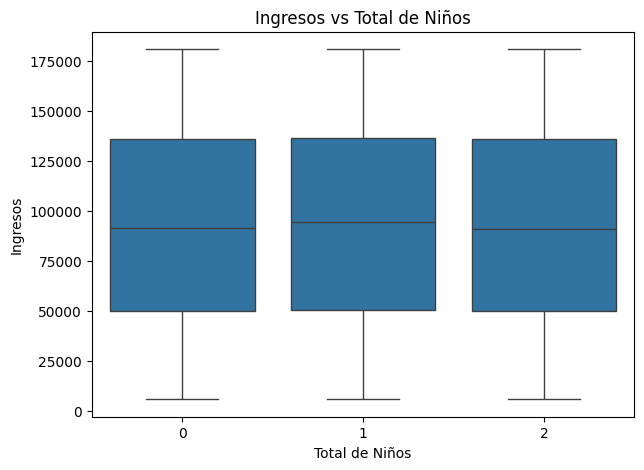

In [41]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Kidhome', y='Income', data=df_2013)
plt.title("Ingresos vs Total de Niños")
plt.xlabel("Total de Niños")
plt.ylabel("Ingresos")
plt.show()

* La mayoría de los clientes con 0 o 1 niño presentan una mediana de ingresos similar, en torno a ~93.000.

* No hay grandes diferencias en el rango de ingresos en función del número de niños.

* Los clientes con 2 niños tienen una ligera disminución en la mediana, pero hay muchísima dispersión en todos los grupos.

* Conclusión: El número total de niños en casa no influye significativamente en los ingresos de los clientes.

### Análisis ingresos vs total de adolescentes en el hogar

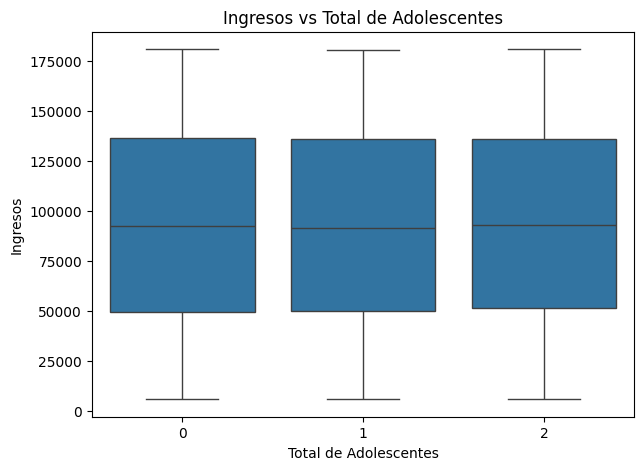

In [42]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Teenhome', y='Income', data=df_2013)
plt.title("Ingresos vs Total de Adolescentes")
plt.xlabel("Total de Adolescentes")
plt.ylabel("Ingresos")
plt.show()

Sigue el mismo patrón que el gráfico de ingresos vs total de niños en el hogar del cliente, por lo que las conclusiones a las que podemos llegar son idénticas.

### Análisis ingresos vs visitas web por mes

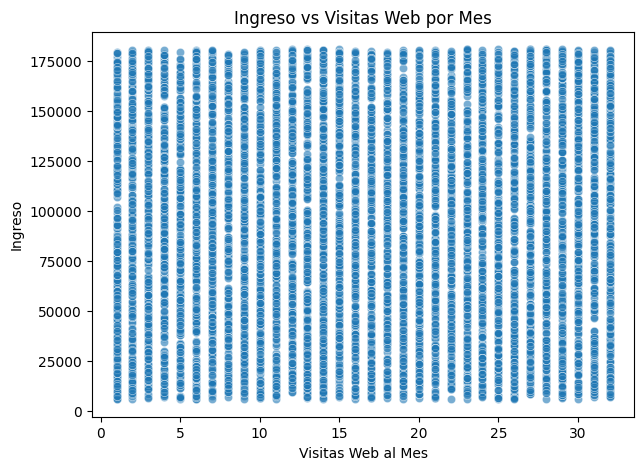

In [43]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='NumWebVisitsMonth', y='Income', data=df_2013, alpha=0.6)
plt.title("Ingreso vs Visitas Web por Mes")
plt.xlabel("Visitas Web al Mes")
plt.ylabel("Ingreso")
plt.show()

* No hay una tendencia clara entre número de visitas y nivel de ingreso.

* La nube de puntos está distribuida horizontalmente, con ingresos altos y bajos en todos los niveles de visitas.

* Conclusión: El número de visitas web mensuales no depende del nivel de ingreso. Esto sugiere que el comportamiento online puede estar influido por otros factores.

### Ingresos según el mes de captación

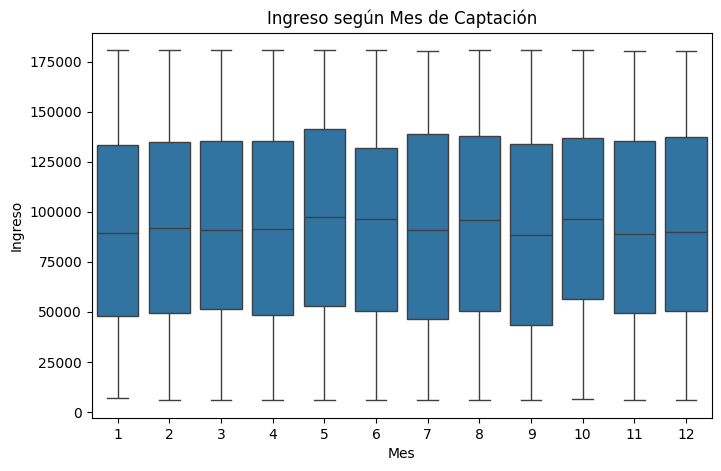

In [44]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Customer_Month', y='Income', data=df_2013)
plt.title("Ingreso según Mes de Captación")
plt.xlabel("Mes")
plt.ylabel("Ingreso")
plt.show()

* La mediana de ingreso es relativamente constante durante todo el año.

* Todos los meses siguen el mismo patrón, no hay apenas variación en cuanto al mes de captación.

* Conclusión: El ingreso no varía significativamente según el mes en que el cliente se une al banco, lo cual es coherente si el banco no filtra por nivel económico a la hora de captar clientes.

## Análisis más profundo

* Distribución de ingresos por número de niños en el hogar.

* Ingresos promedio por número de visitas web.

* Altas clientes por mes.

* Visitas web según mes de captación.

### Distribución de ingresos por número de niños en el hogar

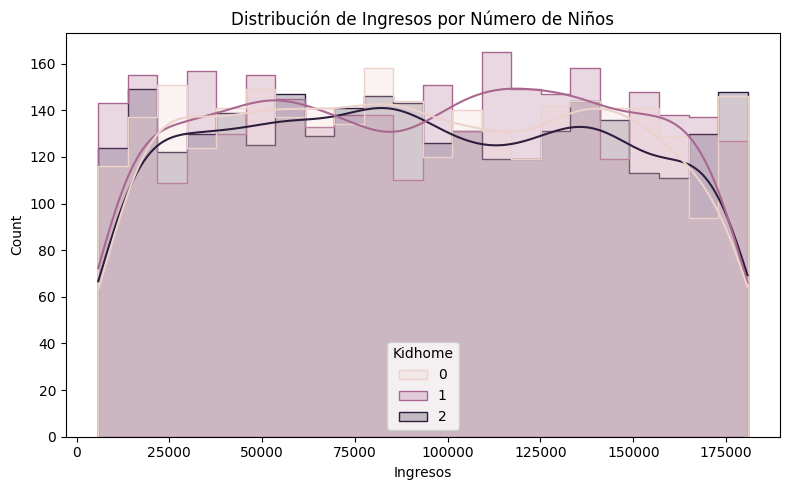

In [45]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_2013, x='Income', hue='Kidhome', kde=True, element='step')
plt.title("Distribución de Ingresos por Número de Niños")
plt.xlabel("Ingresos")
plt.tight_layout()
plt.show()

### Ingresos promedio por número de visitas web

NumWebVisitsMonth
1     87119.560284
2     92479.617978
3     94418.525773
4     94194.329787
5     90157.568421
6     93698.429104
7     94566.129278
8     93693.434944
9     90179.334520
10    91256.297101
11    91635.602837
12    96261.413428
13    88984.482877
14    90364.639344
15    97996.221053
16    92765.145038
17    93489.310861
18    93068.826087
19    90577.652027
20    91135.215548
21    94504.490000
22    94110.827839
23    89819.659498
24    87575.190299
25    90699.870849
26    94573.415094
27    97951.919463
28    90619.932143
29    90341.291391
30    98670.951493
31    96419.092784
32    96014.030201
Name: Income, dtype: float64


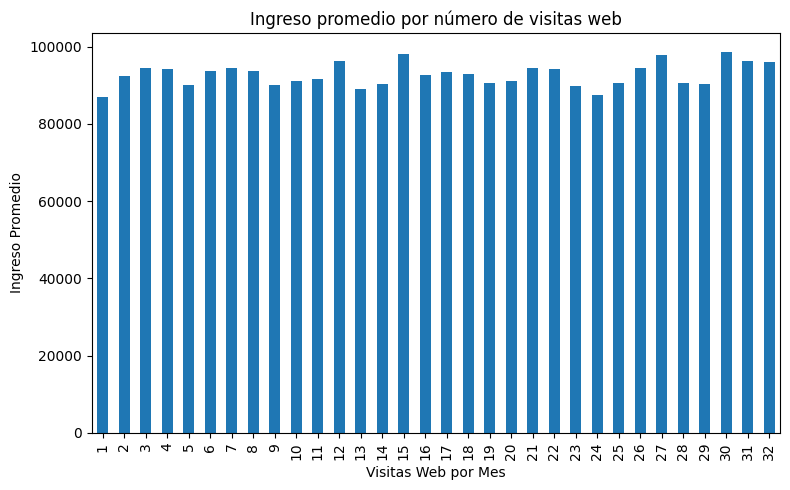

In [46]:
# Agrupación
promedios = df_2013.groupby('NumWebVisitsMonth')['Income'].mean()

# Mostrar resultados
print(promedios)

# Gráfico
plt.figure(figsize=(8, 5))
promedios.plot(kind='bar')
plt.title("Ingreso promedio por número de visitas web")
plt.xlabel("Visitas Web por Mes")
plt.ylabel("Ingreso Promedio")
plt.tight_layout()
plt.show()

### Altas clientes por mes

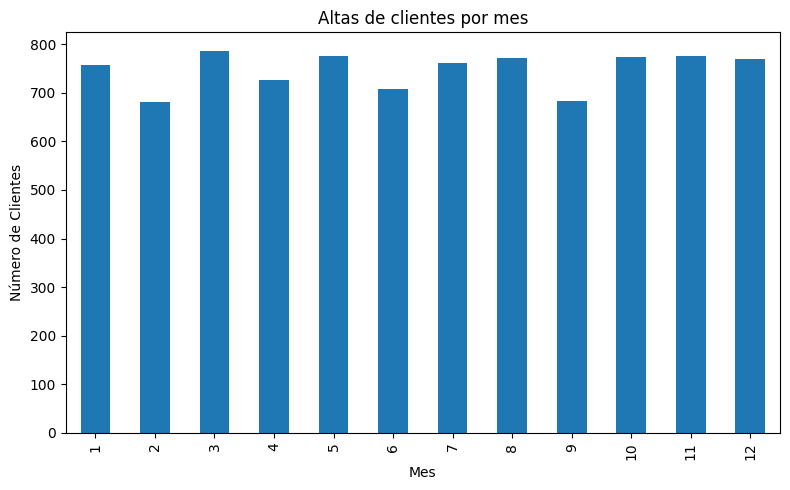

In [47]:
plt.figure(figsize=(8, 5))
df_2013['Customer_Month'].value_counts().sort_index().plot(kind='bar')
plt.title("Altas de clientes por mes")
plt.xlabel("Mes")
plt.ylabel("Número de Clientes")
plt.tight_layout()
plt.show()

### Visitas web según mes de captación

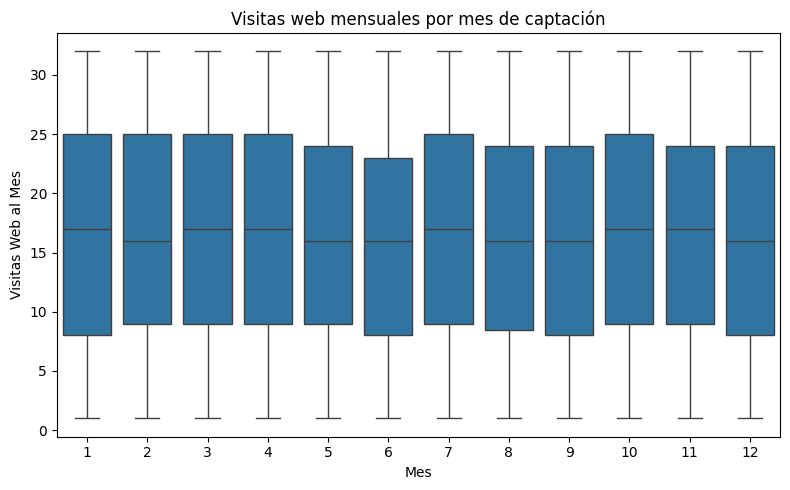

In [48]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Customer_Month', y='NumWebVisitsMonth', data=df_2013)
plt.title("Visitas web mensuales por mes de captación")
plt.xlabel("Mes")
plt.ylabel("Visitas Web al Mes")
plt.tight_layout()
plt.show()

## EDA año 2014

In [49]:
df_2014.head()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,168812,1,1,2014-06-10,27,4d6c811c-0f24-4a73-b374-2ebd1f80d46e
1,1,108615,2,1,2014-04-05,24,eef0f24f-cbdb-4c67-b371-09d7bc59695e
2,2,179041,0,2,2014-09-22,4,bbfdcedd-199d-4927-94bb-5dad051ff471
3,3,116639,2,2,2014-08-16,3,e8ebb67d-4ee1-4615-b701-eefe3af607eb
4,4,49537,0,1,2014-09-05,28,f7f79ace-0024-4505-a401-f340946f0942


### Análisis

In [50]:
def analisis_rapido(df_2014, n=5):
    """ 
    Función que proporciona un análisis rápido del DataFrame.

    Parámetros:
    df: DataFrame
    n: Número de filas (por defecto = 5)
    """

    print(f"Las {n} primeras columnas son:")
    display(df_2014.head(n))
    print("Información básica del DataFrame:")
    display(df_2014.info())

    print(f"El número de duplicados es: {df_2014.duplicated().sum()}")
    display(df_2014.isna().mean().round(4) * 100)

In [51]:
analisis_rapido(df_2014, 3)

Las 3 primeras columnas son:


,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,168812,1,1,2014-06-10,27,4d6c811c-0f24-4a73-b374-2ebd1f80d46e
1,1,108615,2,1,2014-04-05,24,eef0f24f-cbdb-4c67-b371-09d7bc59695e
2,2,179041,0,2,2014-09-22,4,bbfdcedd-199d-4927-94bb-5dad051ff471


Información básica del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14090 entries, 0 to 14089
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         14090 non-null  int64         
 1   Income             14090 non-null  int64         
 2   Kidhome            14090 non-null  int64         
 3   Teenhome           14090 non-null  int64         
 4   Dt_Customer        14090 non-null  datetime64[ns]
 5   NumWebVisitsMonth  14090 non-null  int64         
 6   ID                 14090 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 770.7+ KB


None

El número de duplicados es: 0


Unnamed: 0           0.0
Income               0.0
Kidhome              0.0
Teenhome             0.0
Dt_Customer          0.0
NumWebVisitsMonth    0.0
ID                   0.0
dtype: float64

### Columnas del dataset

●	``income``: Representa el ingreso anual del cliente en términos monetarios.

●	``kidcome``: Indica el número de niños en el hogar del cliente.

●	``teenhome``: Indica el número de adolescentes en el hogar del cliente.

●	``dt_customer``: Representa la fecha en que el cliente se convirtió en cliente de la empresa.

●	``numwebvisitsmonth``: Indica la cantidad de visitas mensuales del cliente al sitio web de la empresa.

●	``id``: Identificador único del cliente.

### EDA

Variables numéricas:

 Index(['Unnamed: 0', 'Income', 'Kidhome', 'Teenhome', 'NumWebVisitsMonth'], dtype='object')

Variables categóricas:

 Index(['ID'], dtype='object')
Veamos las estadísticas básicas:



,count,mean,min,25%,50%,75%,max,std
Unnamed: 0,14090.0,7044.5,0.0,3522.25,7044.5,10566.75,14089.0,4067.576981
Income,14090.0,93706.470405,5841.0,50180.25,93589.0,137195.5,180802.0,50527.970173
Kidhome,14090.0,1.013982,0.0,0.0,1.0,2.0,2.0,0.818562
Teenhome,14090.0,0.999219,0.0,0.0,1.0,2.0,2.0,0.817727
Dt_Customer,14090,2014-07-01 16:25:06.430092288,2014-01-01 00:00:00,2014-04-04 00:00:00,2014-06-30 00:00:00,2014-09-30 00:00:00,2014-12-31 00:00:00,NaN
NumWebVisitsMonth,14090.0,16.673314,1.0,9.0,17.0,25.0,32.0,9.239609


,count,unique,top,freq
ID,14090,14090,9727bc06-c11a-461a-a5bb-3d210467cc2a,1


 
---------- ESTAMOS ANALIZANDO LA COLUMNA: 'ID' ----------
Valores únicos: ['4d6c811c-0f24-4a73-b374-2ebd1f80d46e'
 'eef0f24f-cbdb-4c67-b371-09d7bc59695e'
 'bbfdcedd-199d-4927-94bb-5dad051ff471' ...
 'd6271666-319d-42c8-a741-cb22bf2c2093'
 'f67fbfa8-6573-414d-a805-b26a2f1b1ceb'
 '9727bc06-c11a-461a-a5bb-3d210467cc2a']

Frecuencia de los valores únicos de las categorías


ID
9727bc06-c11a-461a-a5bb-3d210467cc2a    1
4d6c811c-0f24-4a73-b374-2ebd1f80d46e    1
eef0f24f-cbdb-4c67-b371-09d7bc59695e    1
bbfdcedd-199d-4927-94bb-5dad051ff471    1
e8ebb67d-4ee1-4615-b701-eefe3af607eb    1
                                       ..
6a9fd201-56a2-4c1c-8535-1cbca79b9026    1
dff91a78-ff53-4891-b05a-29d0a7607ad9    1
80385078-f477-4a7f-8027-f047ef214f8c    1
11170eb7-770c-49a5-a88d-7f6eff4ce4f3    1
056a5314-a67e-4ff0-964f-256ccdbf10b6    1
Name: count, Length: 14090, dtype: int64

Vayamos con los countplots:

Columna ID tiene demasiadas categorías (14090)


Vayamos con los histogramas:



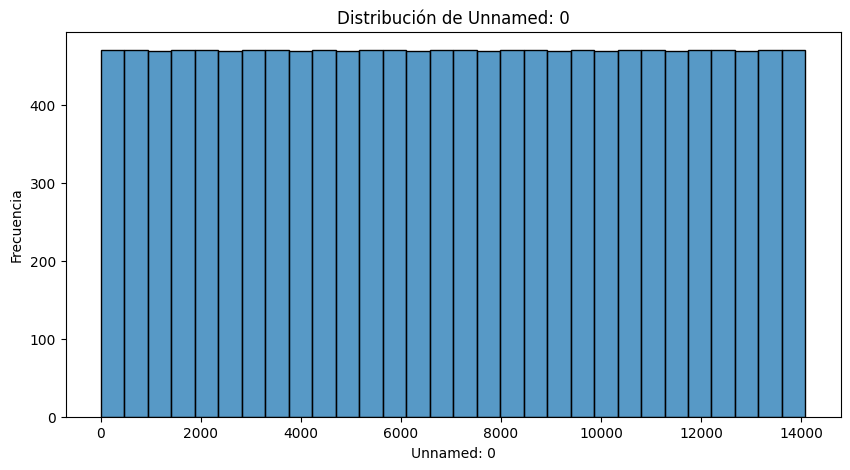

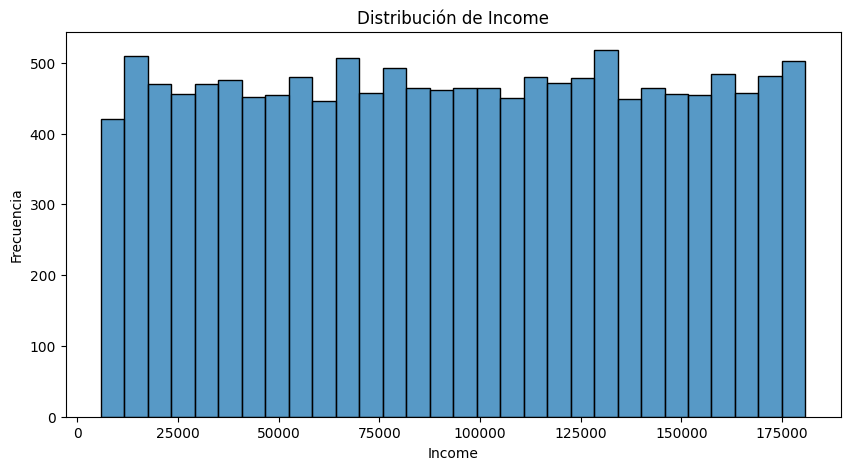

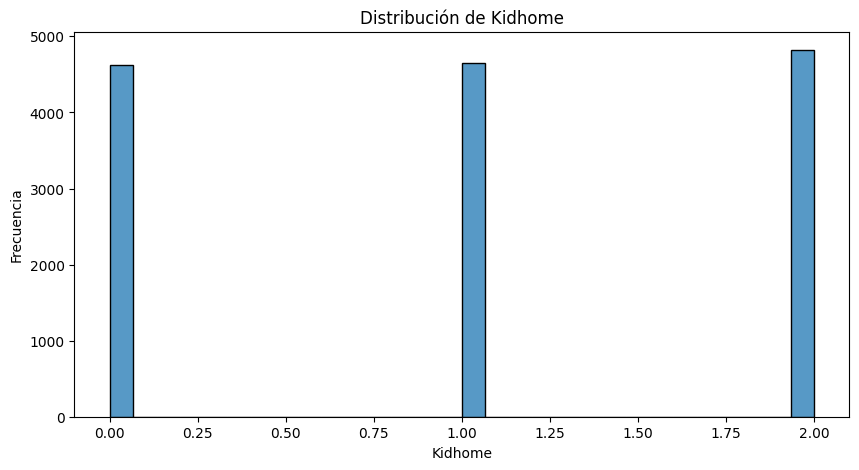

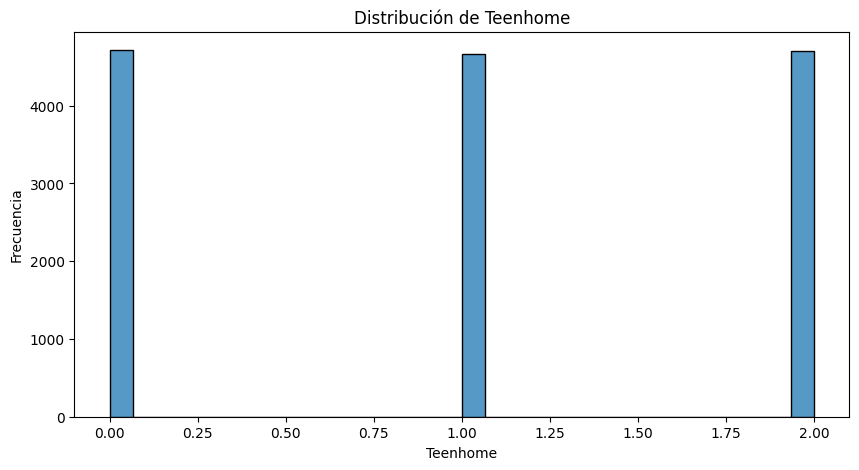

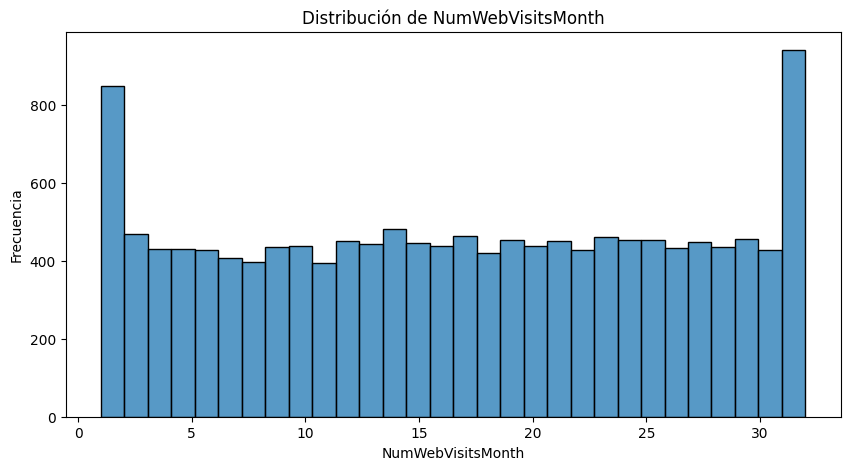

Vayamos con los boxplots:



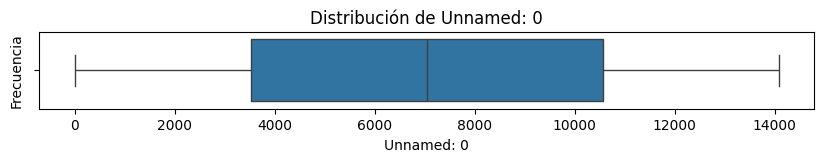

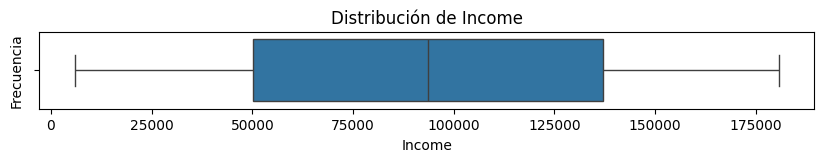

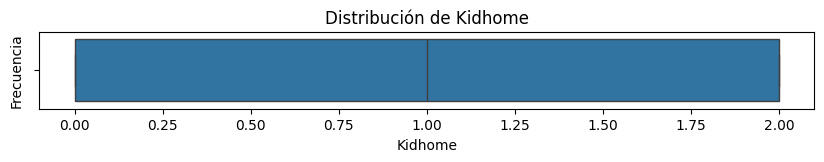

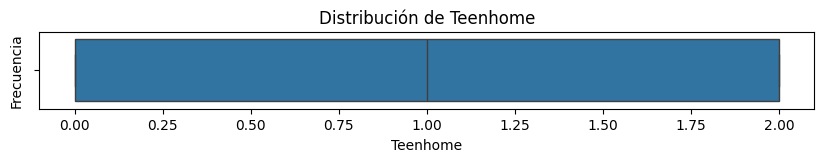

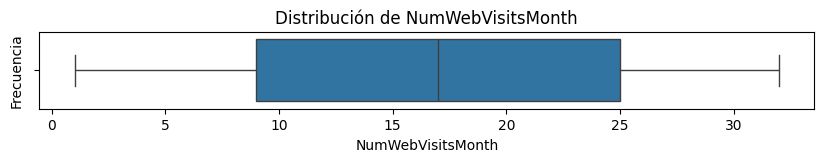

In [52]:
eda(df_2014)

Cómo no coge la colunma `Dt_costumer` haré su análisis de otra manera:

In [53]:
# Convertir la columna a formato fecha

df_2012["Dt_Customer"] = pd.to_datetime(df_2014["Dt_Customer"], errors='coerce')

In [54]:
# Extraer componentes de fecha útiles

df_2014["Customer_Year"] = df_2014["Dt_Customer"].dt.year
df_2014["Customer_Month"] = df_2014["Dt_Customer"].dt.month
df_2014["Customer_Quarter"] = df_2014["Dt_Customer"].dt.to_period("Q")
df_2014["Customer_DayOfWeek"] = df_2014["Dt_Customer"].dt.day_name()


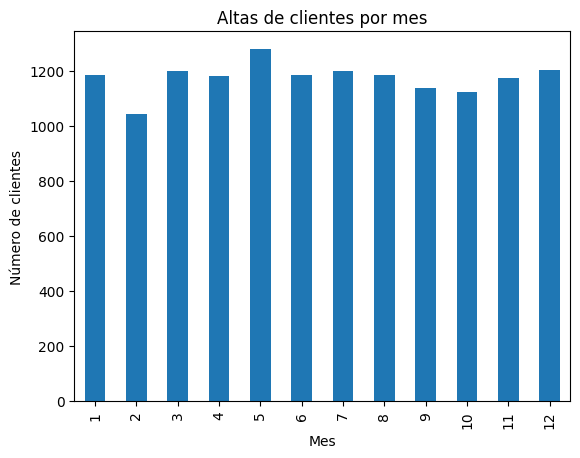

In [55]:
# Visualizar nuevas altas de clientes por mes

df_2014["Customer_Month"].value_counts().sort_index().plot(kind='bar')
plt.title("Altas de clientes por mes")
plt.xlabel("Mes")
plt.ylabel("Número de clientes")
plt.show()

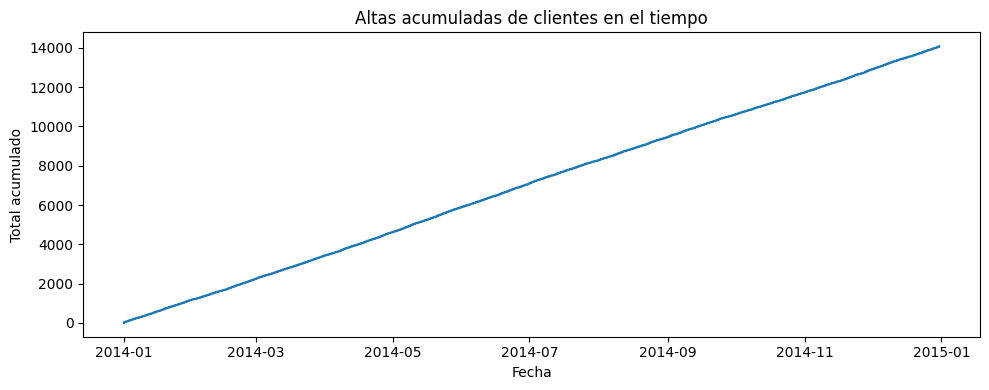

In [56]:
# Altas acumuladas por mes a lo largo del tiempo

df_2014.sort_values("Dt_Customer", inplace=True)
df_2014["Acumulado"] = range(1, len(df_2014)+1)

plt.figure(figsize=(10, 4))
plt.plot(df_2014["Dt_Customer"], df_2014["Acumulado"])
plt.title("Altas acumuladas de clientes en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Total acumulado")
plt.tight_layout()
plt.show()

### Matriz correlación

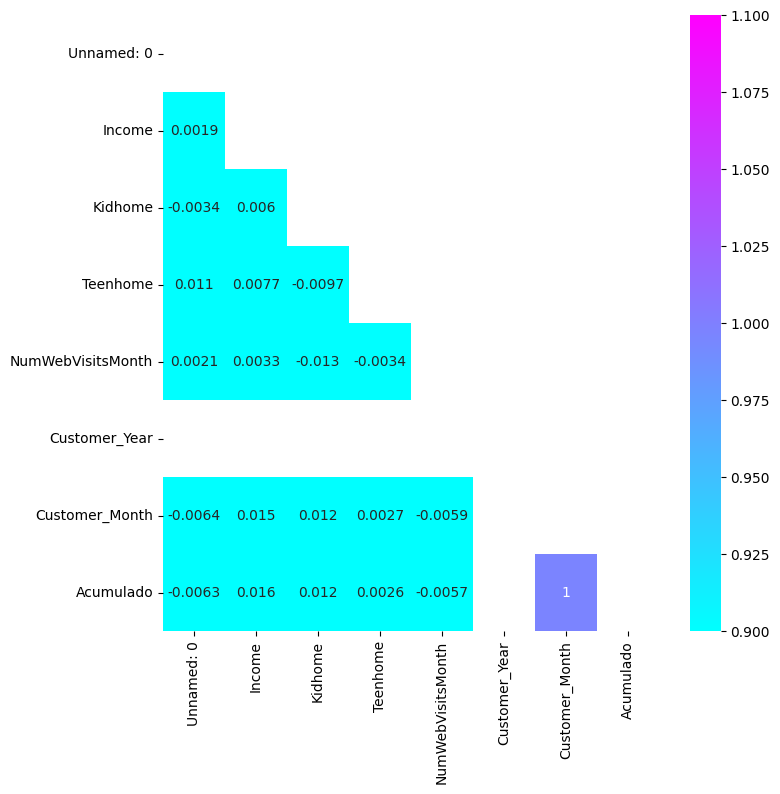

In [57]:
matriz_correlacion(df_2014)

Viendo la matriz correlación sacamos la conclusión de que ninguna variable muestra correlaciones significativas (resultados cercanos a 0).

### Relaciones cruzadas

In [58]:
df_2014.columns

Index(['Unnamed: 0', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer',
       'NumWebVisitsMonth', 'ID', 'Customer_Year', 'Customer_Month',
       'Customer_Quarter', 'Customer_DayOfWeek', 'Acumulado'],
      dtype='object')

### Análisis ingresos vs total de niños en el hogar

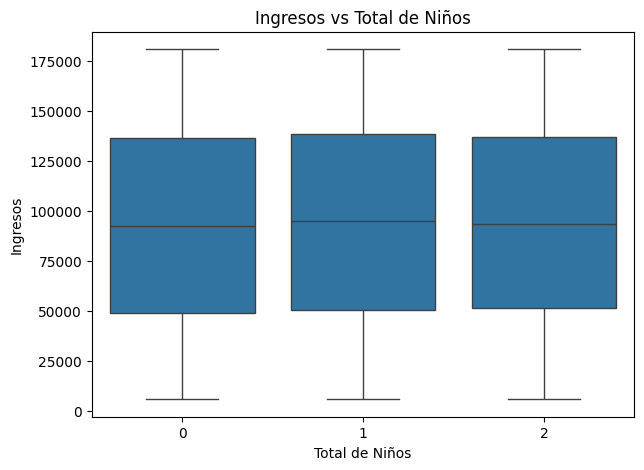

In [59]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Kidhome', y='Income', data=df_2014)
plt.title("Ingresos vs Total de Niños")
plt.xlabel("Total de Niños")
plt.ylabel("Ingresos")
plt.show()

* La mayoría de los clientes con 0 o 1 niño presentan una mediana de ingresos similar, en torno a ~93.000.

* No hay grandes diferencias en el rango de ingresos en función del número de niños.

* Los clientes con 2 niños tienen una ligera disminución en la mediana, pero hay muchísima dispersión en todos los grupos.

* Conclusión: El número total de niños en casa no influye significativamente en los ingresos de los clientes.

### Análisis ingresos vs total de adolescentes en el hogar

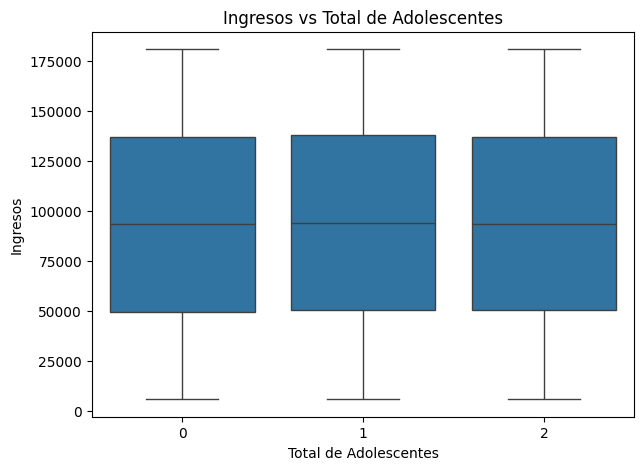

In [60]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Teenhome', y='Income', data=df_2014)
plt.title("Ingresos vs Total de Adolescentes")
plt.xlabel("Total de Adolescentes")
plt.ylabel("Ingresos")
plt.show()

Sigue el mismo patrón que el gráfico de ingresos vs total de niños en el hogar del cliente, por lo que las conclusiones a las que podemos llegar son idénticas.

### Análisis ingresos vs visitas web por mes

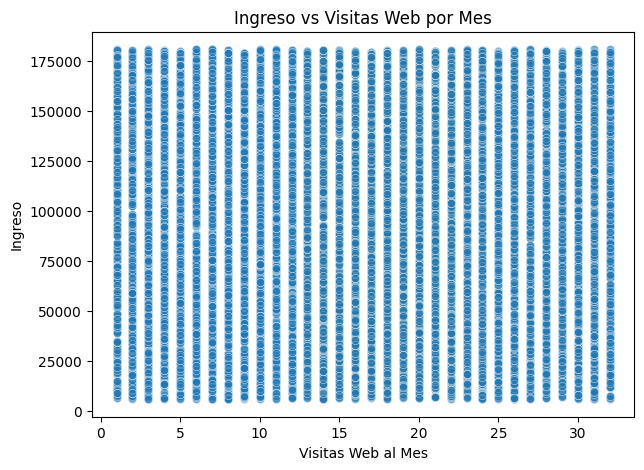

In [61]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='NumWebVisitsMonth', y='Income', data=df_2014, alpha=0.6)
plt.title("Ingreso vs Visitas Web por Mes")
plt.xlabel("Visitas Web al Mes")
plt.ylabel("Ingreso")
plt.show()

* No hay una tendencia clara entre número de visitas y nivel de ingreso.

* La nube de puntos está distribuida horizontalmente, con ingresos altos y bajos en todos los niveles de visitas.

* Conclusión: El número de visitas web mensuales no depende del nivel de ingreso. Esto sugiere que el comportamiento online puede estar influido por otros factores.

### Ingresos según el mes de captación

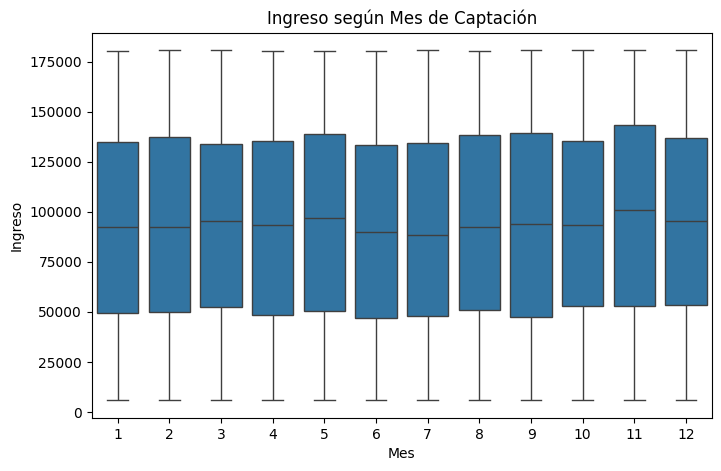

In [62]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Customer_Month', y='Income', data=df_2014)
plt.title("Ingreso según Mes de Captación")
plt.xlabel("Mes")
plt.ylabel("Ingreso")
plt.show()

* La mediana de ingreso es relativamente constante durante todo el año.

* Todos los meses siguen el mismo patrón, no hay apenas variación en cuanto al mes de captación.

* Conclusión: El ingreso no varía significativamente según el mes en que el cliente se une al banco, lo cual es coherente si el banco no filtra por nivel económico a la hora de captar clientes.

## Análisis más profundo

* Distribución de ingresos por número de niños en el hogar.

* Ingresos promedio por número de visitas web.

* Altas clientes por mes.

* Visitas web según mes de captación.

### Distribución de ingresos por número de niños en el hogar

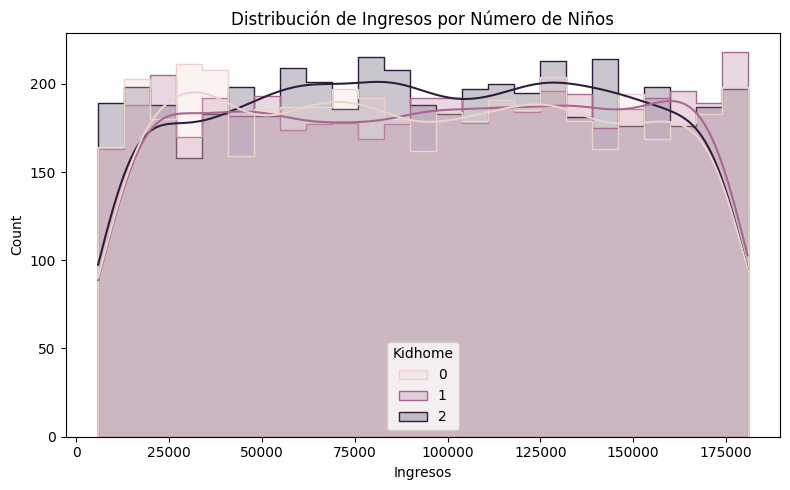

In [63]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_2014, x='Income', hue='Kidhome', kde=True, element='step')
plt.title("Distribución de Ingresos por Número de Niños")
plt.xlabel("Ingresos")
plt.tight_layout()
plt.show()

### Ingresos promedio por número de visitas web

NumWebVisitsMonth
1     91785.822472
2     93150.118812
3     92920.897655
4     94095.988372
5     96826.506977
6     94036.848131
7     89556.571078
8     94289.496222
9     89475.502304
10    94830.899314
11    99162.374684
12    92467.254989
13    92934.006772
14    93435.114583
15    94208.707865
16    94284.871854
17    96844.742981
18    95559.578571
19    91092.139381
20    93381.061785
21    93260.450111
22    93386.806075
23    94270.961039
24    89827.650442
25    96561.000000
26    91727.256944
27    97530.621381
28    93490.620690
29    94235.925439
30    95504.299766
31    89067.193277
32    96001.424569
Name: Income, dtype: float64


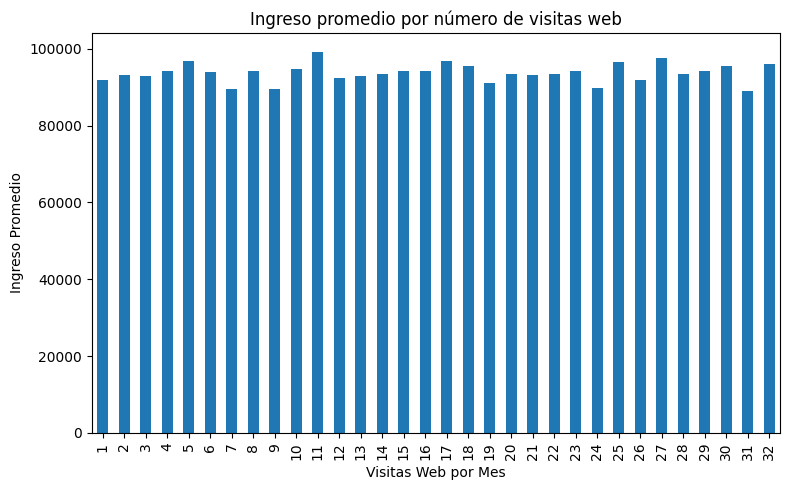

In [64]:
# Agrupación
promedios = df_2014.groupby('NumWebVisitsMonth')['Income'].mean()

# Mostrar resultados
print(promedios)

# Gráfico
plt.figure(figsize=(8, 5))
promedios.plot(kind='bar')
plt.title("Ingreso promedio por número de visitas web")
plt.xlabel("Visitas Web por Mes")
plt.ylabel("Ingreso Promedio")
plt.tight_layout()
plt.show()

### Altas clientes por mes

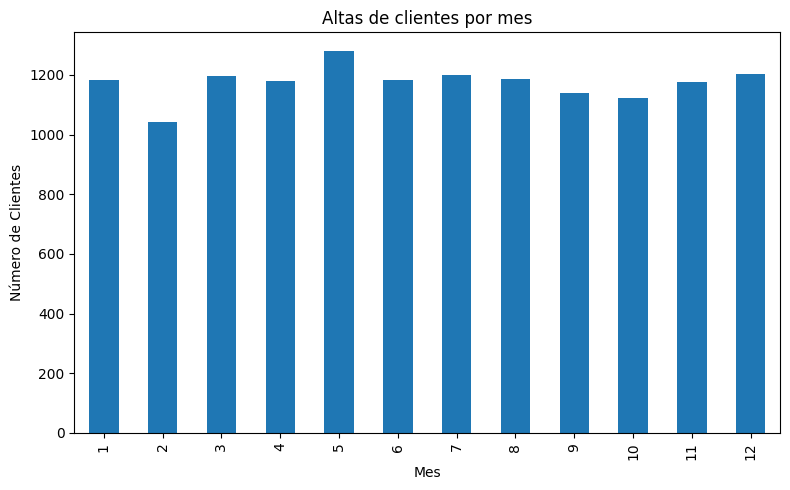

In [65]:
plt.figure(figsize=(8, 5))
df_2014['Customer_Month'].value_counts().sort_index().plot(kind='bar')
plt.title("Altas de clientes por mes")
plt.xlabel("Mes")
plt.ylabel("Número de Clientes")
plt.tight_layout()
plt.show()

### Visitas web según mes de captación

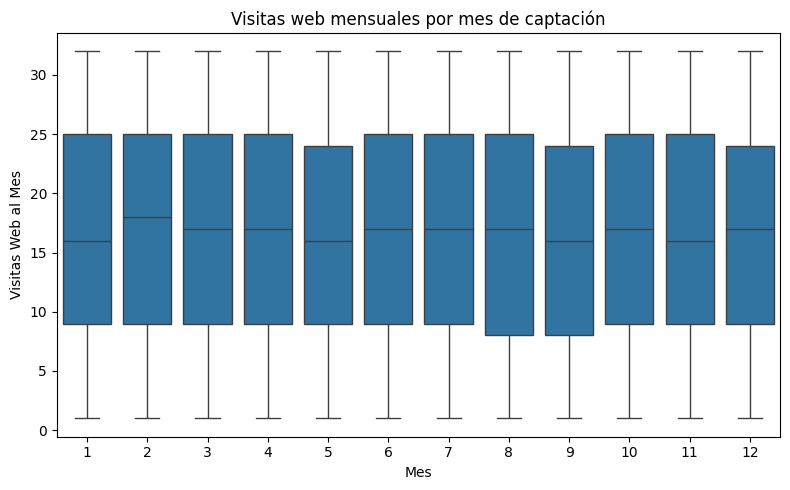

In [66]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Customer_Month', y='NumWebVisitsMonth', data=df_2014)
plt.title("Visitas web mensuales por mes de captación")
plt.xlabel("Mes")
plt.ylabel("Visitas Web al Mes")
plt.tight_layout()
plt.show()